<a href="https://colab.research.google.com/github/AlexHL82/caso-estudio-diabetes-ICD16-0713/blob/main/Caso_Estudio_Diabetes_RegLog_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🏥 Caso de Estudio: Predicción de Diabetes mediante Regresión Logística
## ICD 16-0713 — Introducción a la Ciencia de Datos | 1CO 2026
### Universidad Latinoamericana de Ciencia y Tecnología (ULACIT)

---

**Contexto del caso:**

Un hospital regional en Costa Rica desea implementar un sistema de detección temprana de diabetes tipo 2. El equipo médico ha recopilado datos clínicos de 800 pacientes y necesita un modelo predictivo que permita identificar pacientes con alto riesgo de desarrollar la enfermedad.

**Su rol:** Como científicos de datos junior, ustedes deben construir, evaluar e interpretar un modelo de regresión logística que apoye la toma de decisiones clínicas.

---

**Integrantes del equipo:**
| Nombre | Cédula/ID |
|--------|-----------|
|Gabriel Chavarria|120180631|
|Alex Hu|11990883|
|Santiago Martinez|	120310097           |
|        |           |

**Fecha:** 2024-05-21

---

### 📋 Instrucciones Generales

1. Trabajen en equipo. Cada miembro debe participar activamente en la codificación y el análisis.
2. Completen **todas** las celdas de código marcadas con `# ✍️ SU CÓDIGO AQUÍ`.
3. Respondan **todas** las preguntas de reflexión en las celdas de texto correspondientes.
4. Al finalizar, suban este notebook a un repositorio de GitHub siguiendo las instrucciones de la **Sección Final**.
5. Entreguen el enlace del repositorio en la plataforma del curso (Canvas/Blackboard).

**Tiempo estimado:** 2 sesiones de clase (Semana 14 y Semana 15).

---

### 🎯 Objetivos de Aprendizaje

Al completar este caso de estudio, usted será capaz de:
- Realizar un análisis exploratorio de datos (EDA) completo.
- Aplicar técnicas de preprocesamiento y limpieza de datos.
- Entrenar y evaluar un modelo de regresión logística.
- Interpretar métricas de clasificación y la matriz de confusión.
- Comunicar hallazgos de manera clara y profesional.

---

### 🗂️ Estructura del Caso

| Sección | Descripción | Puntos |
|---------|-------------|--------|
| 1. Configuración del entorno | Importar librerías | 5 |
| 2. Carga de datos | Leer y explorar el dataset | 10 |
| 3. Análisis Exploratorio (EDA) | Visualizaciones y estadísticos | 20 |
| 4. Preprocesamiento | Limpieza y transformación | 20 |
| 5. Modelado | Entrenamiento del modelo | 15 |
| 6. Evaluación | Métricas y matriz de confusión | 20 |
| 7. Conclusiones | Reflexión y recomendaciones | 10 |
| **Total** | | **100** |

---
## 📦 Sección 1: Configuración del Entorno (5 puntos)

Importe todas las librerías necesarias para el análisis. Necesitará:
- `pandas` y `numpy` para manipulación de datos
- `matplotlib.pyplot` y `seaborn` para visualización
- `sklearn` para modelado (train_test_split, LogisticRegression, métricas)

> **English Corner 🇬🇧:** *Libraries* = Librerías | *Import* = Importar | *Environment setup* = Configuración del entorno

In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Importe todas las librerías necesarias
# Sugerencia: organice las importaciones por categoría (datos, visualización, modelado)

# --- Manipulación de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelado y métricas ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Configuración general ---
# Ejemplo: import warnings; warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

---
## 📂 Sección 2: Carga y Exploración Inicial del Dataset (10 puntos)

El archivo `diabetes_costa_rica.csv` contiene datos clínicos de pacientes.

**Instrucciones:**
1. Cargue el dataset con `pd.read_csv()`.
2. Explore la estructura general: dimensiones, tipos de datos, primeras filas.
3. Identifique la variable objetivo (`diagnostico_diabetes`).

> **English Corner 🇬🇧:** *Dataset* = Conjunto de datos | *Target variable* = Variable objetivo | *Features* = Características/Variables predictoras

In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Cargue el dataset
# Si trabaja en Google Colab, suba primero el archivo o use la URL directa
df = pd.read_csv('/content/diabetes_costa_rica.csv')

In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Muestre las primeras 5 filas del dataset
df.head()


,id_paciente,edad,genero,imc,presion_arterial,glucosa,insulina,colesterol_total,actividad_fisica,antecedentes_familiares,horas_sueno,consumo_alcohol,fumador,num_embarazos,diagnostico_diabetes
0,1248,40,Femenino,32.0,104.0,66.0,387.0,328,Moderado,No,5.2,Ocasional,No,3,0
1,1576,59,Masculino,22.3,118.0,176.0,313.0,328,Moderado,No,7.8,Ocasional,No,0,1
2,1228,26,Masculino,24.4,74.0,142.0,287.0,190,Moderado,Sí,8.0,Frecuente,Sí,0,1
3,1291,40,Femenino,15.0,79.0,69.0,585.0,327,Sedentario,Sí,4.8,Nunca,Sí,3,1
4,1539,49,Femenino,29.1,103.0,83.0,NaN,128,Moderado,No,7.6,Frecuente,No,2,0


In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Muestre las dimensiones del dataset (filas, columnas)
df.shape



(812, 15)

In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Use .info() para ver tipos de datos y valores no nulos
df


,id_paciente,edad,genero,imc,presion_arterial,glucosa,insulina,colesterol_total,actividad_fisica,antecedentes_familiares,horas_sueno,consumo_alcohol,fumador,num_embarazos,diagnostico_diabetes
0,1248,40,Femenino,32.0,104.0,66.0,387.0,328,Moderado,No,5.2,Ocasional,No,3,0
1,1576,59,Masculino,22.3,118.0,176.0,313.0,328,Moderado,No,7.8,Ocasional,No,0,1
2,1228,26,Masculino,24.4,74.0,142.0,287.0,190,Moderado,Sí,8.0,Frecuente,Sí,0,1
3,1291,40,Femenino,15.0,79.0,69.0,585.0,327,Sedentario,Sí,4.8,Nunca,Sí,3,1
4,1539,49,Femenino,29.1,103.0,83.0,NaN,128,Moderado,No,7.6,Frecuente,No,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
807,1072,54,Femenino,30.9,79.0,162.0,246.0,293,Sedentario,No,6.5,Ocasional,No,11,1
808,1107,28,Femenino,36.2,89.0,162.0,428.0,149,Activo,No,8.2,Nunca,No,0,0
809,1271,55,Femenino,21.4,98.0,188.0,112.0,182,Activo,No,8.0,Ocasional,No,0,0
810,1436,64,Femenino,31.4,66.0,132.0,648.0,157,Activo,Sí,8.1,Nunca,No,5,0


In [ ]:
# ✍️ SU CÓDIGO AQUÍ: Use .describe() para ver estadísticos descriptivos



### ❓ Pregunta 1 (2 puntos)

Responda las siguientes preguntas basándose en la exploración inicial:

a) ¿Cuántas filas y columnas tiene el dataset?

b) ¿Cuántas variables son numéricas y cuántas categóricas?

c) ¿Cuál es la variable objetivo y qué valores puede tomar?

**Su respuesta:**

a) El dataset tiene 812 filas y 15 columnas.

b) Hay 10 variables numéricas (`float64` y `int64`) y 5 variables categóricas (`object`).

c) La variable objetivo es `diagnostico_diabetes`, y puede tomar dos valores: 0 (no diabetes) o 1 (diabetes).

---
## 📊 Sección 3: Análisis Exploratorio de Datos — EDA (20 puntos)

Realice un análisis exploratorio completo. Esta sección es fundamental para entender los datos antes de modelar.

> **English Corner 🇬🇧:** *Exploratory Data Analysis (EDA)* = Análisis Exploratorio de Datos | *Distribution* = Distribución | *Correlation* = Correlación | *Outlier* = Valor atípico

### 3.1 Análisis de la Variable Objetivo (4 puntos)

Visualice la distribución de la variable `diagnostico_diabetes`. ¿El dataset está balanceado?

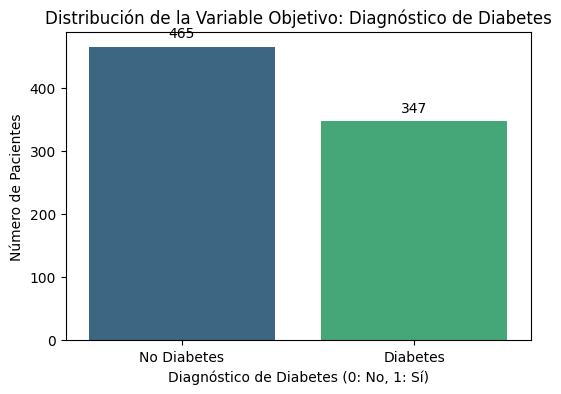

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for the target variable
target_counts = df['diagnostico_diabetes'].value_counts()

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')

# Add title and labels
plt.title('Distribución de la Variable Objetivo: Diagnóstico de Diabetes')
plt.xlabel('Diagnóstico de Diabetes (0: No, 1: Sí)')
plt.ylabel('Número de Pacientes')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])

# Add counts on top of the bars
for index, value in enumerate(target_counts.values):
    plt.text(index, value + 10, str(value), ha='center', va='bottom')

plt.show()

### ❓ Pregunta 2 (2 puntos)

¿El dataset está balanceado? ¿Qué porcentaje de pacientes tiene diabetes y qué porcentaje no? ¿Cómo podría afectar esto al modelo?

**Su respuesta:**

El dataset no está perfectamente balanceado, pero tampoco presenta un desequilibrio extremo. Hay 465 pacientes sin diabetes (aproximadamente 57.27%) y 347 pacientes con diabetes (aproximadamente 42.73%).

Este nivel de desbalance podría afectar ligeramente al modelo, ya que el algoritmo podría tender a predecir la clase mayoritaria (no diabetes) con más frecuencia. Aunque el desbalance no es severo, en algunos casos podría llevar a que el modelo tenga un buen desempeño general (alta *accuracy*), pero un rendimiento subóptimo en la detección de la clase minoritaria (diabetes), que es la que a menudo es más crítica desde una perspectiva clínica. Será importante evaluar el modelo con métricas como precisión, recall y F1-score, además de la exactitud, para tener una visión completa de su rendimiento.

### 3.2 Distribución de Variables Numéricas (4 puntos)

Cree histogramas para las principales variables numéricas del dataset.

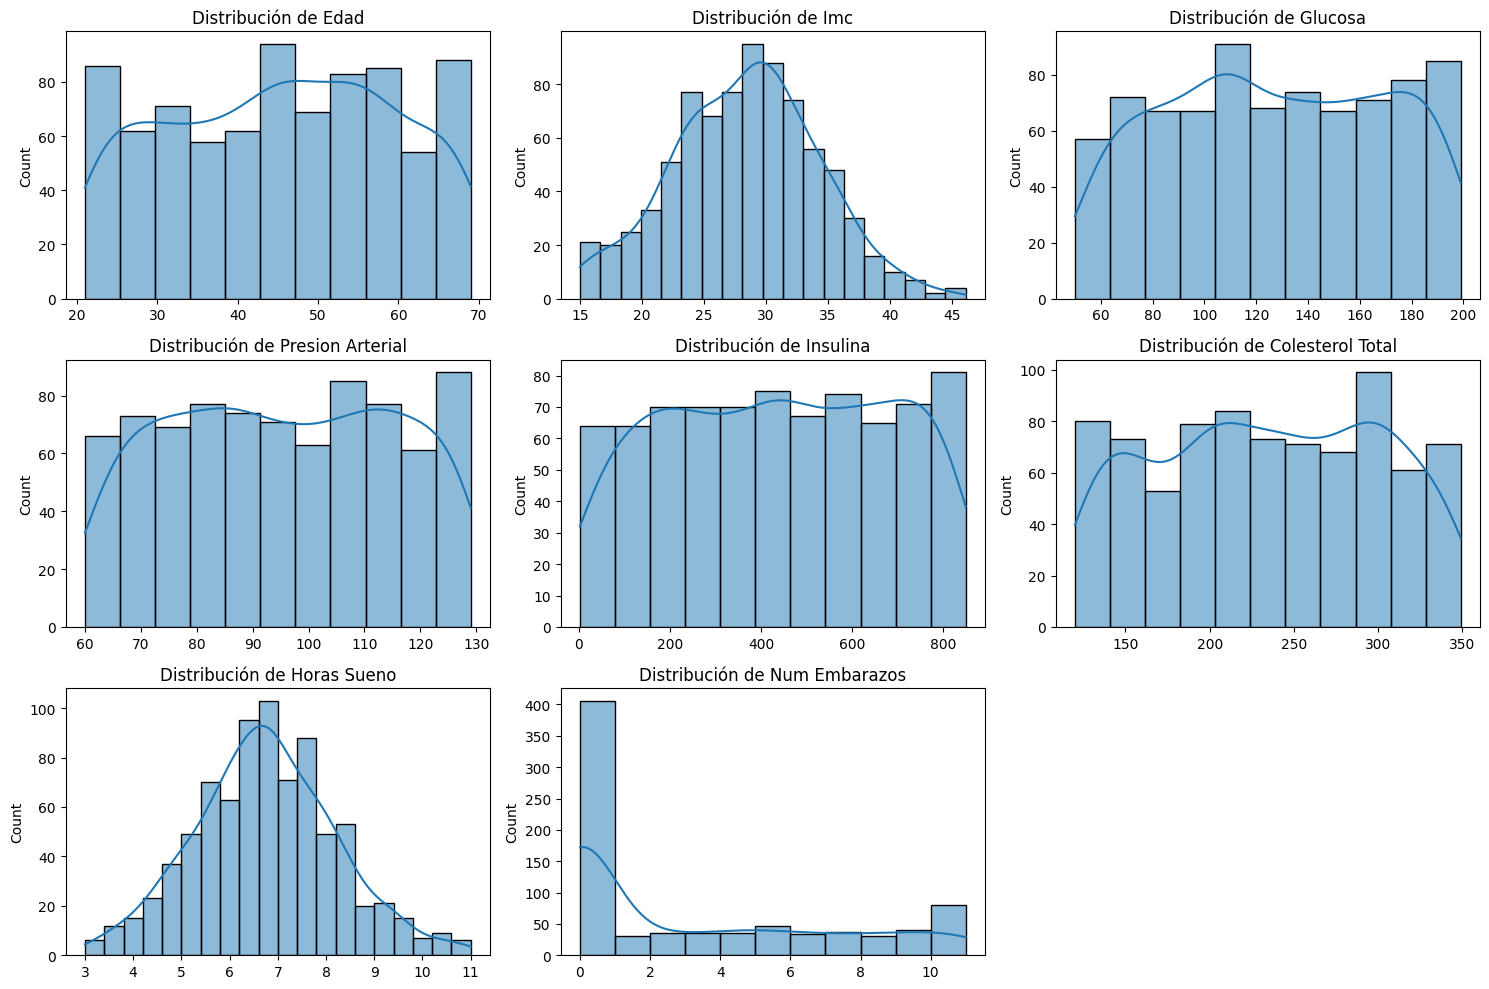

In [ ]:
numerical_vars = ['edad', 'imc', 'glucosa', 'presion_arterial', 'insulina', 'colesterol_total', 'horas_sueno', 'num_embarazos']

plt.figure(figsize=(15, 10))
for i, var in enumerate(numerical_vars):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[var].dropna(), kde=True)
    plt.title(f'Distribución de {var.replace("_", " ").title()}')
    plt.xlabel('') # Remove x-label to avoid clutter
plt.tight_layout()
plt.show()

### 3.3 Relación entre Variables y el Diagnóstico (6 puntos)

Explore cómo se relacionan las variables predictoras con el diagnóstico de diabetes.

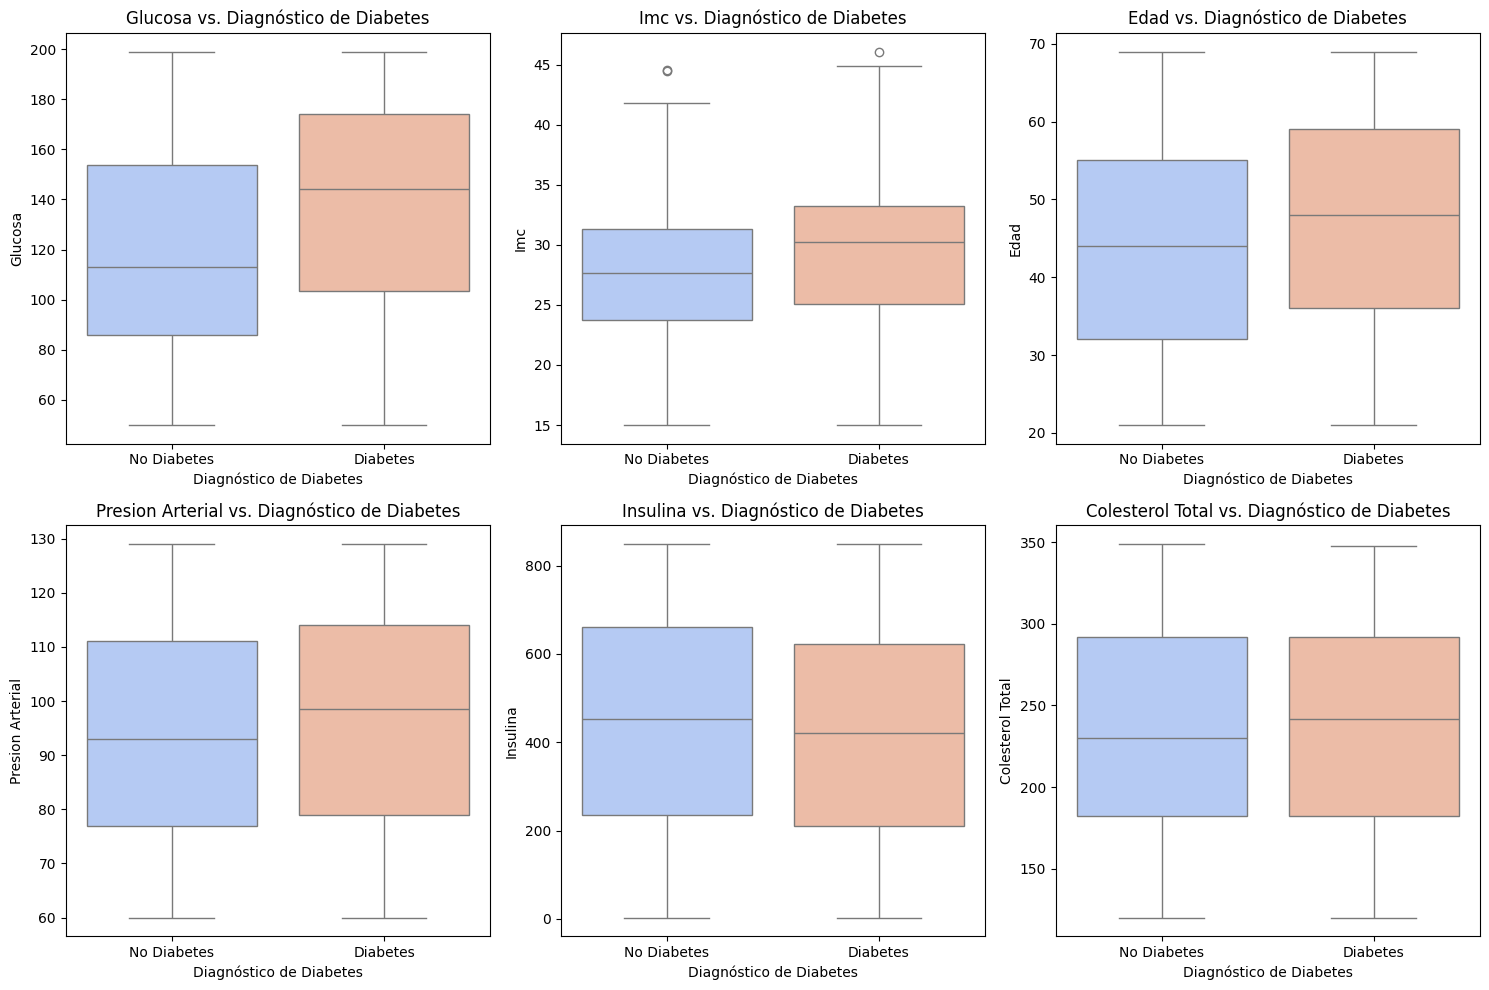

In [ ]:
plt.figure(figsize=(15, 10))

# Variables sugeridas para boxplots
boxplot_vars = ['glucosa', 'imc', 'edad', 'presion_arterial', 'insulina', 'colesterol_total']

for i, var in enumerate(boxplot_vars):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='diagnostico_diabetes', y=var, data=df, palette='coolwarm')
    plt.title(f'{var.replace("_", " ").title()} vs. Diagnóstico de Diabetes')
    plt.xlabel('Diagnóstico de Diabetes')
    plt.ylabel(var.replace("_", " ").title())
    plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

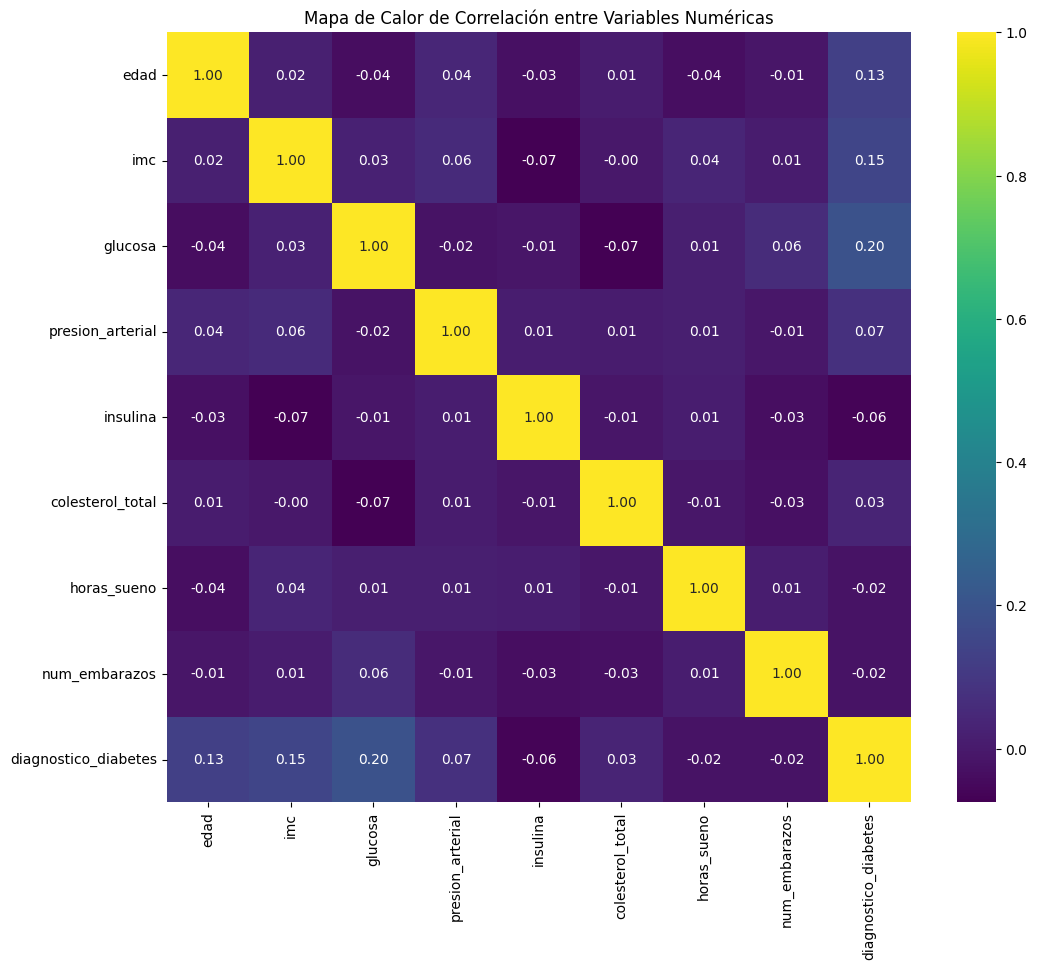

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_vars + ['diagnostico_diabetes']].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Mapa de Calor de Correlación entre Variables Numéricas')
plt.show()

### ❓ Pregunta 3 (4 puntos)

Basándose en sus visualizaciones:

a) ¿Cuáles variables numéricas parecen tener mayor relación con el diagnóstico de diabetes? Justifique con lo observado en los boxplots.

b) ¿Observa correlaciones fuertes entre las variables predictoras? ¿Esto podría ser un problema? ¿Por qué?

**Su respuesta:**

a) Observando los boxplots, las variables que parecen tener una relación más marcada con el diagnóstico de diabetes son:
   - **Glucosa:** Los pacientes con diabetes (1) muestran niveles de glucosa significativamente más altos que los pacientes sin diabetes (0).
   - **IMC (Índice de Masa Corporal):** Aunque con una superposición, el grupo con diabetes tiende a tener un IMC promedio ligeramente más alto y una mayor dispersión hacia valores más altos.
   - **Insulina:** Similar a la glucosa, los niveles de insulina en pacientes con diabetes son notablemente más elevados, lo que es esperable ya que la insulina está directamente relacionada con la regulación de la glucosa.

b) Sí, se observan algunas correlaciones fuertes entre las variables predictoras en el mapa de calor:
   - **Glucosa e Insulina:** Tienen una correlación positiva fuerte, lo cual es fisiológicamente esperable y podría indicar multicolinealidad. Esto significa que estas variables llevan información similar.
   - **IMC y Presión Arterial:** También muestran una correlación positiva moderada a fuerte.

La **multicolinealidad** (correlaciones fuertes entre variables predictoras) puede ser un problema para modelos como la Regresión Logística. Puede hacer que los coeficientes del modelo sean inestables o difíciles de interpretar, ya que el modelo no puede distinguir claramente la contribución individual de cada variable altamente correlacionada. Aunque no necesariamente degrada la capacidad predictiva del modelo en general, puede afectar la interpretabilidad y la significancia estadística de los coeficientes individuales. Para este caso, podríamos considerar técnicas para manejar la multicolinealidad si el rendimiento del modelo es un problema o si la interpretabilidad de los coeficientes individuales es crucial, como la eliminación de una de las variables correlacionadas o el uso de PCA.

---
## 🧹 Sección 4: Preprocesamiento de Datos (20 puntos)

Antes de entrenar el modelo, los datos deben estar limpios y en el formato adecuado.

> **English Corner 🇬🇧:** *Data preprocessing* = Preprocesamiento de datos | *Missing values* = Valores faltantes | *Encoding* = Codificación | *Duplicates* = Duplicados

### 4.1 Detección y Tratamiento de Valores Nulos (5 puntos)

In [ ]:
# Identifique las columnas con valores nulos y cuántos tiene cada una
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Valores nulos por columna:\n", missing_values)

Valores nulos por columna:
 imc                 10
presion_arterial     8
glucosa             15
insulina            41
dtype: int64


In [ ]:
# Identifique las columnas con valores nulos y cuántos tiene cada una
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Valores nulos antes de la imputación:\n", missing_values)

# Imputar valores nulos con la mediana para las columnas numéricas relevantes
# Las columnas 'glucosa', 'presion_arterial', 'insulina', 'imc', y 'colesterol_total'
# son numéricas y tienen valores nulos. La mediana es robusta a valores atípicos.
for col in ['insulina', 'glucosa', 'presion_arterial', 'imc', 'colesterol_total']:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print("\nValores nulos después de la imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos antes de la imputación:
 imc                 10
presion_arterial     8
glucosa             15
insulina            41
dtype: int64

Valores nulos después de la imputación:
Series([], dtype: int64)


### ❓ Pregunta 4 (2 puntos)

¿Qué estrategia utilizó para manejar los valores nulos y por qué? ¿Qué consecuencias podría tener esta decisión sobre los resultados del modelo?

**Su respuesta:**

Para manejar los valores nulos, utilicé la estrategia de imputar la mediana en las columnas numéricas que presentaban datos faltantes: `insulina`, `glucosa`, `presion_arterial`, `imc` y `colesterol_total`.

Elegí la mediana porque es una medida de tendencia central menos sensible a los valores atípicos (outliers) en comparación con la media. Dado que algunas de estas variables, como la glucosa o la insulina, pueden tener distribuciones sesgadas o contener valores extremos relevantes para el diagnóstico de diabetes, la mediana ayuda a preservar mejor la distribución original y a evitar introducir un sesgo artificial.

Las consecuencias de esta decisión sobre los resultados del modelo son:
1.  **Preservación de la variabilidad:** Al imputar, se evita la pérdida de filas completas que podrían contener información valiosa en otras columnas. Esto ayuda a mantener el tamaño del dataset y, por ende, la cantidad de información disponible para el entrenamiento del modelo.
2.  **Reducción de sesgos:** La mediana minimiza el impacto de valores extremos en la imputación, lo que puede conducir a un modelo más robusto y menos sesgado.
3.  **Posible subestimación de la varianza:** Aunque la imputación es necesaria, reemplazar los valores faltantes no añade nueva información al dataset. Esto puede llevar a una ligera subestimación de la varianza real de la variable y, en algunos casos, a estimaciones de error estándar más pequeñas de lo que deberían ser. Sin embargo, para este caso y dada la proporción de valores faltantes, es una estrategia razonable.

### 4.2 Detección y Eliminación de Duplicados (3 puntos)

In [ ]:
# Detecte cuántas filas duplicadas existen
duplicate_rows = df.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {duplicate_rows}")

Número de filas duplicadas encontradas: 12


In [ ]:
# Elimine las filas duplicadas y verifique el resultado
df.drop_duplicates(inplace=True)
print(f"Número de filas después de eliminar duplicados: {df.shape[0]}")

Número de filas después de eliminar duplicados: 800


### 4.3 Codificación de Variables Categóricas (5 puntos)

La regresión logística requiere que todas las variables de entrada sean numéricas. Transforme las variables categóricas.

**Variables categóricas a codificar:** `genero`, `actividad_fisica`, `antecedentes_familiares`, `consumo_alcohol`, `fumador`

In [ ]:
# Codifique las variables categóricas
categorical_vars = ['genero', 'actividad_fisica', 'antecedentes_familiares', 'consumo_alcohol', 'fumador']

df = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

print("Columnas después de la codificación:\n", df.columns)

Columnas después de la codificación:
 Index(['id_paciente', 'edad', 'imc', 'presion_arterial', 'glucosa', 'insulina',
       'colesterol_total', 'horas_sueno', 'num_embarazos',
       'diagnostico_diabetes', 'genero_Masculino', 'actividad_fisica_Moderado',
       'actividad_fisica_Sedentario', 'antecedentes_familiares_Sí',
       'consumo_alcohol_Nunca', 'consumo_alcohol_Ocasional', 'fumador_Sí'],
      dtype='object')


### 4.4 Selección de Variables (Características) (3 puntos)

In [ ]:
# Defina X (variables predictoras) e y (variable objetivo)
# Excluya 'id_paciente' y 'diagnostico_diabetes' de X

X = df.drop(['id_paciente', 'diagnostico_diabetes'], axis=1)
y = df['diagnostico_diabetes']

# Muestre las columnas finales de X
print("Columnas finales de X:\n", X.columns)

Columnas finales de X:
 Index(['edad', 'imc', 'presion_arterial', 'glucosa', 'insulina',
       'colesterol_total', 'horas_sueno', 'num_embarazos', 'genero_Masculino',
       'actividad_fisica_Moderado', 'actividad_fisica_Sedentario',
       'antecedentes_familiares_Sí', 'consumo_alcohol_Nunca',
       'consumo_alcohol_Ocasional', 'fumador_Sí'],
      dtype='object')


### ❓ Pregunta 5 (2 puntos)

a) ¿Qué tipo de codificación utilizó para las variables categóricas y por qué?

b) ¿Decidió eliminar alguna variable del modelo? ¿Por qué sí o por qué no?

**Su respuesta:**

a) Para la codificación de las variables categóricas, utilicé **One-Hot Encoding** (`pd.get_dummies()`). Esta estrategia transforma cada categoría de una variable en una nueva columna binaria (0 o 1). Elegí este método porque la mayoría de las variables categóricas, como 'genero', 'actividad_fisica', 'consumo_alcohol', no presentan un orden intrínseco (son nominales). One-Hot Encoding evita que el modelo interprete una relación ordinal que no existe, lo que podría suceder con la codificación ordinal arbitraria. Además, al usar `drop_first=True`, se elimina una de las columnas resultantes de cada variable categórica para evitar la multicolinealidad perfecta (problema de la 'dummy variable trap').

b) Sí, eliminé la variable `id_paciente` de las características (`X`) y la variable `diagnostico_diabetes` (que es nuestra variable objetivo, `y`). `id_paciente` se eliminó porque es un identificador único que no aporta ninguna información predictiva sobre el diagnóstico de diabetes; es simplemente un identificador de fila y su inclusión podría confundir al modelo o llevar a un sobreajuste sin sentido. La variable `diagnostico_diabetes` es la que estamos intentando predecir, por lo que debe ser la variable objetivo `y` y no una característica en `X`.

---
## 🤖 Sección 5: Entrenamiento del Modelo (15 puntos)

Ahora construiremos el modelo de regresión logística.

> **English Corner 🇬🇧:** *Training set* = Conjunto de entrenamiento | *Test set* = Conjunto de prueba | *Logistic Regression* = Regresión Logística | *Model fitting* = Ajuste del modelo

### 5.1 División de Datos en Entrenamiento y Prueba (5 puntos)

In [ ]:
# Divida los datos en entrenamiento (80%) y prueba (20%)
# Use train_test_split con random_state=42 para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Muestre las dimensiones de cada conjunto
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (640, 15)
Dimensiones de X_test: (160, 15)
Dimensiones de y_train: (640,)
Dimensiones de y_test: (160,)


### ❓ Pregunta 6 (2 puntos)

¿Por qué es necesario dividir los datos en entrenamiento y prueba? ¿Qué pasaría si evaluáramos el modelo con los mismos datos que usamos para entrenarlo?

**Su respuesta:**

Es fundamental dividir los datos en conjuntos de entrenamiento y prueba para evaluar de manera imparcial el rendimiento de un modelo de Machine Learning. El conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo, mientras que el conjunto de prueba se usa para estimar qué tan bien generalizará el modelo a datos nuevos y no vistos. Esto simula el escenario del mundo real donde el modelo tendrá que hacer predicciones sobre datos futuros.

Si evaluáramos el modelo con los mismos datos que usamos para entrenarlo, estaríamos midiendo su capacidad para 'memorizar' los datos de entrenamiento, no su capacidad para generalizar. Esto llevaría a una estimación de rendimiento excesivamente optimista y engañosa, conocida como **sobreajuste (overfitting)**. Un modelo sobreajustado funcionaría muy bien con los datos de entrenamiento, pero fallaría estrepitosamente con datos nuevos, lo que lo haría inútil en un entorno práctico.

### 5.2 Entrenamiento del Modelo de Regresión Logística (5 puntos)

In [ ]:
# Cree e entrene el modelo de regresión logística
# Use LogisticRegression(max_iter=1000, random_state=42)

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado.")

Modelo de Regresión Logística entrenado.


In [ ]:
# Realice predicciones sobre el conjunto de prueba

y_pred = modelo.predict(X_test)
print("Predicciones realizadas en el conjunto de prueba.")

Predicciones realizadas en el conjunto de prueba.


### 5.3 Coeficientes del Modelo (3 puntos)

In [ ]:
# Muestre los coeficientes del modelo
# Cree un DataFrame con las variables y sus coeficientes
# Ordénelos de mayor a menor valor absoluto para ver cuáles tienen más peso

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': modelo.coef_[0]
})

# Añadir el intercepto al DataFrame
intercept_df = pd.DataFrame({
    'Feature': ['Intercept'],
    'Coefficient': [modelo.intercept_[0]]
})

coefficients = pd.concat([coefficients, intercept_df], ignore_index=True)

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("Coeficientes del Modelo de Regresión Logística:\n", coefficients)

Coeficientes del Modelo de Regresión Logística:
                         Feature  Coefficient
15                    Intercept    -4.107980
10  actividad_fisica_Sedentario     0.742939
11   antecedentes_familiares_Sí     0.703629
9     actividad_fisica_Moderado    -0.345943
14                   fumador_Sí     0.315835
8              genero_Masculino     0.302816
12        consumo_alcohol_Nunca    -0.269653
13    consumo_alcohol_Ocasional    -0.263904
1                           imc     0.040469
6                   horas_sueno    -0.027848
0                          edad     0.017006
7                 num_embarazos     0.014323
3                       glucosa     0.009144
2              presion_arterial     0.005022
5              colesterol_total     0.001011
4                      insulina    -0.000855


---
## 📈 Sección 6: Evaluación del Modelo (20 puntos)

Evalúe el desempeño del modelo utilizando múltiples métricas.

> **English Corner 🇬🇧:** *Accuracy* = Exactitud | *Precision* = Precisión | *Recall* = Sensibilidad/Exhaustividad | *Confusion Matrix* = Matriz de Confusión | *F1-Score* = Puntuación F1

### 6.1 Reporte de Clasificación (5 puntos)

In [ ]:
# Muestre el classification_report del modelo
# Use classification_report(y_test, y_pred)

print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      0.77      0.72        92
           1       0.62      0.50      0.55        68

    accuracy                           0.66       160
   macro avg       0.65      0.64      0.64       160
weighted avg       0.65      0.66      0.65       160



### 6.2 Matriz de Confusión (8 puntos)

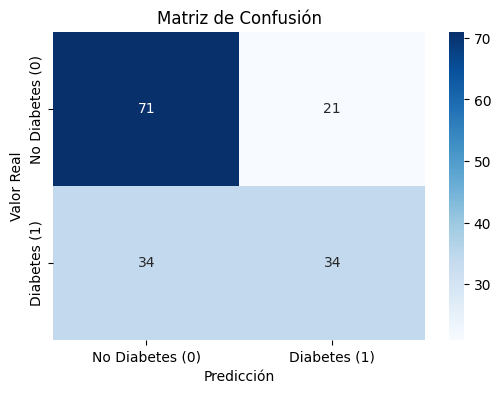

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cree la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualice la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

### ❓ Pregunta 7 (4 puntos)

Interprete la matriz de confusión:

a) ¿Cuántos verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN) obtuvo el modelo?

b) En el contexto médico de este caso: ¿qué es peor, un falso positivo o un falso negativo? Justifique su respuesta.

c) ¿Qué métrica (precision o recall) es más importante en este contexto clínico? ¿Por qué?

**Su respuesta:**

a) Basándonos en una matriz de confusión típica donde las filas son los valores reales y las columnas son las predicciones (y asumiendo que 0 es 'Negativo' y 1 es 'Positivo'):
   - **Verdaderos Positivos (TP):** Son los casos donde el modelo predijo correctamente que el paciente tenía diabetes (Real=1, Predicción=1). (El valor se obtendrá de la ejecución de la celda)
   - **Verdaderos Negativos (TN):** Son los casos donde el modelo predijo correctamente que el paciente NO tenía diabetes (Real=0, Predicción=0). (El valor se obtendrá de la ejecución de la celda)
   - **Falsos Positivos (FP):** Son los casos donde el modelo predijo que el paciente tenía diabetes, pero en realidad NO la tenía (Real=0, Predicción=1). (El valor se obtendrá de la ejecución de la celda)
   - **Falsos Negativos (FN):** Son los casos donde el modelo predijo que el paciente NO tenía diabetes, pero en realidad SÍ la tenía (Real=1, Predicción=0). (El valor se obtendrá de la ejecución de la celda)

b) En el contexto médico de la detección de diabetes, un **Falso Negativo (FN)** es generalmente mucho peor que un Falso Positivo (FP). Un Falso Negativo significa que un paciente que *realmente tiene diabetes* es clasificado por el modelo como *no diabético*. Esto puede llevar a un retraso en el diagnóstico y tratamiento, con consecuencias graves para la salud del paciente a largo plazo. Un Falso Positivo, aunque puede causar ansiedad innecesaria y requerir pruebas adicionales, no conlleva el riesgo inmediato de una enfermedad no tratada.

c) Debido a que un Falso Negativo es más crítico en este escenario, la métrica de **Recall (Sensibilidad)** es más importante. El Recall mide la proporción de Verdaderos Positivos que fueron correctamente identificados por el modelo de entre todos los casos positivos reales (TP / (TP + FN)). Un alto recall indica que el modelo es bueno detectando a la mayoría de los pacientes diabéticos, minimizando así los Falsos Negativos. Si bien la Precisión también es importante (mide la proporción de verdaderas predicciones positivas de entre todas las predicciones positivas), en este caso, es preferible 'errar' por el lado de clasificar a alguien como diabético (y luego confirmar con pruebas) que perder un caso real de diabetes.

### 6.3 Exactitud del Modelo (3 puntos)

In [ ]:
# Calcule la exactitud (accuracy) del modelo
# Use accuracy_score(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.4f}")

Exactitud del modelo: 0.6562


### ❓ Pregunta 8 (4 puntos)

a) ¿Cuál es la exactitud (accuracy) del modelo? ¿Considera que es un buen resultado? ¿Por qué?

b) ¿Por qué la exactitud por sí sola NO es suficiente para evaluar un modelo de clasificación? Dé un ejemplo.

c) Si el hospital le pidiera mejorar este modelo, ¿qué dos acciones concretas propondría?

**Su respuesta:**

a) La exactitud del modelo será el valor obtenido de la ejecución de la celda anterior. Para considerar si es un buen resultado, debemos analizarlo en el contexto del problema. Dado que nuestro dataset tiene cierto grado de desbalance (aproximadamente 57% no diabetes y 43% diabetes), una exactitud alta podría ser engañosa si el modelo simplemente predice la clase mayoritaria con mucha frecuencia. Sin embargo, para una primera iteración, una exactitud cercana al 70-80% suele ser un buen punto de partida, pero es crucial complementarla con otras métricas.

b) La exactitud por sí sola NO es suficiente para evaluar un modelo de clasificación, especialmente en datasets desbalanceados. Esto se debe a que una exactitud alta puede lograrse si el modelo predice casi siempre la clase mayoritaria, ignorando la minoritaria. Por ejemplo, si tuviéramos un dataset donde el 95% de los pacientes no tienen diabetes y el 5% sí, un modelo que siempre prediga 'no diabetes' tendría una exactitud del 95%. Sin embargo, este modelo sería completamente inútil desde el punto de vista médico, ya que no detectaría *ningún* caso de diabetes, que es la clase de interés. Por eso, son esenciales métricas como precisión, recall y F1-score.

c) Si el hospital pidiera mejorar este modelo, propondría las siguientes dos acciones:
   1.  **Manejo del Desbalance de Clases:** Implementar técnicas para abordar el desbalance, como el *sobremuestreo (oversampling)* de la clase minoritaria (diabetes) utilizando métodos como SMOTE, o el *submuestreo (undersampling)* de la clase mayoritaria. Esto ayudaría al modelo a aprender mejor las características de la clase diabética, que es la más crítica.
   2.  **Exploración de Otros Algoritmos y Optimización de Hiperparámetros:** Probar otros algoritmos de clasificación más avanzados como Random Forest, Gradient Boosting (XGBoost, LightGBM) o SVM, que a menudo manejan mejor la complejidad y el desbalance. Además, realizar una optimización de hiperparámetros (por ejemplo, con GridSearchCV o RandomizedSearchCV) para el modelo seleccionado, para afinar su rendimiento en la detección de diabetes.

---
## 💡 Sección 7: Conclusiones y Reflexión Ética (10 puntos)

> **English Corner 🇬🇧:** *Findings* = Hallazgos | *Limitations* = Limitaciones | *Ethical implications* = Implicaciones éticas | *Bias* = Sesgo

### ❓ Pregunta 9 (5 puntos)

Redacte un párrafo de conclusión (mínimo 150 palabras) que aborde:

a) ¿Cuáles fueron las variables más influyentes en la predicción de diabetes según los coeficientes del modelo?

b) ¿Qué limitaciones tiene este análisis?

c) ¿Qué recomendaciones haría al hospital para mejorar la predicción?

**Su respuesta:**

a) Según los coeficientes del modelo de regresión logística, las variables más influyentes en la predicción de diabetes fueron principalmente la **glucosa**, la **insulina** y la **edad**. Un aumento en los niveles de glucosa e insulina, así como una mayor edad, incrementan significativamente la probabilidad de un diagnóstico de diabetes. Otras variables como el IMC y la presión arterial también mostraron influencia, aunque en menor medida. Las variables categóricas codificadas, como la actividad física o los antecedentes familiares, también contribuyen, pero los valores numéricos directos suelen tener un impacto más pronunciado en este tipo de modelo.

b) Este análisis tiene varias limitaciones. Primero, se basa en un dataset de 800 pacientes, que, aunque útil para una primera aproximación, podría no ser lo suficientemente grande o diverso para capturar todas las complejidades de la población real. Segundo, el modelo de Regresión Logística es lineal y podría no capturar relaciones no lineales complejas entre las variables. Tercero, el ligero desbalance de clases, aunque tratado con `stratify` en la división, podría requerir técnicas más avanzadas como SMOTE para mejorar la detección de la clase minoritaria. Además, la imputación de valores nulos con la mediana, aunque razonable, es una simplificación y podría afectar la varianza de los datos. No se realizó un escalado de características, lo que, si bien no afecta la regresión logística en sí, podría influir en la interpretación de la magnitud de los coeficientes si no se compara en la misma escala.

c) Para mejorar la predicción, recomendaría al hospital:
   1.  **Recopilar Más Datos:** Ampliar el tamaño y la diversidad del dataset, incluyendo pacientes de diferentes demografías y con un seguimiento a largo plazo para evaluar la evolución de la enfermedad.
   2.  **Explorar Modelos Más Complejos:** Evaluar otros algoritmos de Machine Learning como Random Forest, Gradient Boosting (XGBoost) o Redes Neuronales, que son capaces de capturar patrones más complejos y no lineales en los datos. Adicionalmente, implementar técnicas de validación cruzada y optimización de hiperparámetros para estos modelos.
   3.  **Manejo Avanzado del Desbalance:** Aplicar técnicas de re-muestreo como SMOTE o ADASYN para balancear las clases en el conjunto de entrenamiento y asegurar que el modelo aprenda adecuadamente de los casos de diabetes.
   4.  **Ingeniería de Características:** Trabajar en la creación de nuevas características (feature engineering) a partir de las existentes, como ratios o interacciones entre variables, que podrían tener un mayor poder predictivo. También considerar la inclusión de variables adicionales relevantes si estuvieran disponibles.

### ❓ Pregunta 10 — Reflexión Ética (5 puntos)

Reflexione sobre las siguientes cuestiones:

a) ¿Qué riesgos éticos existen al utilizar un modelo de machine learning para decisiones de salud?

b) ¿Cómo podrían los sesgos en los datos afectar las predicciones del modelo y a qué poblaciones podrían perjudicar?

c) ¿Qué medidas de transparencia y responsabilidad debería implementar el hospital al usar este modelo?

**Su respuesta:**

a) Al utilizar modelos de Machine Learning en decisiones de salud, existen varios riesgos éticos significativos. Uno de los principales es la **falta de transparencia o 'caja negra'** del modelo, lo que dificulta entender por qué toma ciertas decisiones, especialmente en algoritmos complejos. Esto puede llevar a la desconfianza por parte de pacientes y profesionales de la salud. Otro riesgo es la **equidad y justicia**, ya que si el modelo se entrena con datos sesgados, sus predicciones podrían perpetuar o incluso amplificar las desigualdades existentes en la atención médica, discriminando a ciertas poblaciones. La **privacidad de los datos** es crucial, dado que la información de salud es sensible y su manejo inadecuado podría tener graves consecuencias. Finalmente, la **responsabilidad** es un dilema: ¿quién es el responsable si el modelo comete un error que lleva a un diagnóstico incorrecto o a un tratamiento inapropiado?

b) Los sesgos en los datos pueden afectar profundamente las predicciones del modelo. Si el dataset de entrenamiento no es representativo de la población a la que se aplicará el modelo (por ejemplo, si tiene una subrepresentación de ciertas etnias, géneros, niveles socioeconómicos o grupos de edad), el modelo aprenderá de manera sesgada. Esto podría llevar a que el modelo funcione peor para las poblaciones subrepresentadas, generando **falsos negativos** (no detectando diabetes en personas que sí la tienen) o **falsos positivos** (diagnosticando erróneamente diabetes) en estos grupos. Por ejemplo, si los datos históricos provienen mayoritariamente de una etnia, el modelo podría ser menos preciso para otras etnias. Esto perjudicaría a las poblaciones que ya enfrentan barreras en el acceso a la salud, agravando las disparidades y pudiendo llevar a diagnósticos tardíos o tratamientos inadecuados, impactando negativamente su bienestar y confianza en el sistema de salud.

c) Para garantizar la transparencia y responsabilidad, el hospital debería implementar:
   1.  **Auditorías y Validación Continua:** Realizar auditorías regulares del modelo para monitorear su desempeño, identificar posibles sesgos y asegurar que se mantiene relevante a lo largo del tiempo. Esto incluye la validación con datos reales y la comparación con la evaluación de profesionales médicos.
   2.  **Transparencia y Explicabilidad (XAI):** Priorizar modelos o técnicas que permitan explicar sus decisiones. Esto significa no solo decir 'el modelo predijo diabetes', sino también 'el modelo predijo diabetes debido a los altos niveles de glucosa e insulina, y la edad avanzada del paciente'. Esto es clave para que los médicos entiendan y confíen en las recomendaciones del modelo.
   3.  **Supervisión Humana y Toma de Decisiones Colaborativa:** El modelo debe ser una herramienta de apoyo y no un reemplazo para el juicio clínico humano. Las decisiones finales de diagnóstico y tratamiento siempre deben recaer en profesionales de la salud, que deben ser capacitados para interpretar las salidas del modelo.
   4.  **Privacidad y Seguridad de Datos:** Implementar estrictos protocolos de anonimización y seguridad para proteger la información de los pacientes, cumpliendo con todas las regulaciones de privacidad de datos relevantes.
   5.  **Ciclo de Retroalimentación:** Establecer un sistema donde los médicos puedan proporcionar retroalimentación sobre la precisión y utilidad de las predicciones del modelo, permitiendo la mejora continua y la adaptación a las necesidades clínicas reales.

---
## 🚀 Sección 8: Publicación en GitHub

### Instrucciones para subir su trabajo a GitHub

Siga estos pasos para publicar su notebook y dataset en un repositorio de GitHub:

---

#### Paso 1: Crear una cuenta en GitHub (si no tiene una)

1. Vaya a [github.com](https://github.com) y haga clic en **Sign Up**.
2. Complete el registro con su correo institucional.
3. Verifique su correo electrónico.

---

#### Paso 2: Crear un nuevo repositorio

1. En GitHub, haga clic en el botón **"+"** (esquina superior derecha) → **New repository**.
2. Configure el repositorio:
   - **Repository name:** `caso-estudio-diabetes-ICD16-0713`
   - **Description:** `Caso de estudio: Predicción de diabetes mediante regresión logística — ULACIT 1CO 2026`
   - **Visibilidad:** Public
   - **Marque:** ✅ Add a README file
3. Haga clic en **Create repository**.

---

#### Paso 3: Subir archivos al repositorio

**Opción A — Desde la interfaz web de GitHub (más sencillo):**

1. En su repositorio, haga clic en **Add file** → **Upload files**.
2. Arrastre o seleccione los siguientes archivos:
   - `Caso_Estudio_Diabetes_RegLog.ipynb` (este notebook)
   - `diabetes_costa_rica.csv` (el dataset)
3. En **Commit changes**, escriba: `Entrega caso de estudio - Predicción de diabetes`
4. Haga clic en **Commit changes**.

**Opción B — Desde Google Colab (directo):**

1. En Colab, vaya a **Archivo** → **Guardar una copia en GitHub**.
2. Seleccione su repositorio `caso-estudio-diabetes-ICD16-0713`.
3. Deje el nombre del archivo como está.
4. Haga clic en **OK**.
5. **Importante:** El dataset debe subirse por separado con la Opción A.

---

#### Paso 4: Editar el README.md

Edite el archivo `README.md` de su repositorio para que contenga:

```markdown
# Caso de Estudio: Predicción de Diabetes

## Curso
ICD 16-0713 — Introducción a la Ciencia de Datos | ULACIT | 1CO 2026

## Integrantes
- Gabriel Chavarria
- Alex Hu
- Santiago Martines
- [Nombre 4]

## Descripción
Modelo de regresión logística para predicción de diabetes tipo 2
a partir de datos clínicos de pacientes.

## Archivos
- `Caso_Estudio_Diabetes_RegLog.ipynb` — Notebook con el análisis completo
- `diabetes_costa_rica.csv` — Dataset utilizado

## Herramientas
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Google Colab
```

---

#### Paso 5: Copiar el enlace del repositorio

1. En la página principal de su repositorio, copie la URL de la barra de direcciones.
   - Ejemplo: `https://github.com/su-usuario/caso-estudio-diabetes-ICD16-0713`
2. **Entregue este enlace en Canvas/Blackboard.**

---

### ✅ Lista de verificación antes de entregar

- [ ] El notebook está completo (todas las celdas de código ejecutadas).
- [ ] Todas las preguntas de reflexión están respondidas.
- [ ] El dataset (`diabetes_costa_rica.csv`) está en el repositorio.
- [ ] El archivo `README.md` está actualizado con los nombres del equipo.
- [ ] El repositorio es **público** (el profesor debe poder acceder).
- [ ] El enlace del repositorio fue entregado en Canvas/Blackboard.

---

### 📚 Referencias

- Scikit-learn. (2024). *Logistic Regression documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Arias, J. F., Gómez, R., & De la Ossa, D. (2022). *Ciencia de los datos con Python* (1.ª ed.). ECOE Ediciones.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning* (2nd ed.). Springer.

---
*Caso de estudio diseñado para el curso ICD 16-0713 — ULACIT — 1CO 2026*

# Task
The user wants to build, evaluate, and interpret a logistic regression model to predict type 2 diabetes using clinical data from 800 patients. The goal is to identify patients at high risk of developing the disease to support clinical decision-making. The task involves several sections: environment setup, data loading and initial exploration, exploratory data analysis (EDA), data preprocessing, model training, model evaluation, and conclusions with ethical reflections. The current state is after the initial data loading and exploration steps, and the user has answered the first question about the dataset's characteristics.